In [1]:
import numpy as np
from io import StringIO

# proliferating e-anyons, m-anyons subthreshold

data_str1 = """ 0.437200 0.444100 0.471200 0.493600 0.517300 0.537800 0.559400 0.576500
0.431900 0.453000 0.472000 0.492900 0.514000 0.538400 0.555700 0.578300
0.432200 0.454100 0.474300 0.494500 0.511100 0.530600 0.555700 0.584200
0.424600 0.449000 0.475000 0.496700 0.518300 0.532700 0.556500 0.581700
0.409100 0.424100 0.447400 0.479300 0.495700 0.523400 0.555100 0.569100
0.400700 0.423100 0.444600 0.468300 0.500500 0.527400 0.555800 0.578800
0.396800 0.422700 0.448300 0.482700 0.497100 0.527600 0.542400 0.576000
0.401600 0.423300 0.454000 0.477300 0.504700 0.524000 0.553600 0.573100
0.372800 0.411400 0.433200 0.465400 0.480200 0.516700 0.545600 0.582300
0.377000 0.408700 0.430000 0.461300 0.487000 0.518600 0.544400 0.580400
0.371300 0.403600 0.426600 0.466000 0.492000 0.523400 0.538700 0.574800
0.372800 0.402700 0.440400 0.453300 0.487400 0.524000 0.545100 0.572800
0.344100 0.392500 0.415600 0.436000 0.478800 0.514900 0.539600 0.575600
0.346100 0.382500 0.414400 0.445500 0.486200 0.500200 0.529500 0.574900
0.352100 0.378400 0.414900 0.441500 0.474500 0.508300 0.544600 0.582800
0.354100 0.384900 0.411000 0.447100 0.467800 0.497800 0.540200 0.572800 """
data_str2 = """ 0.510600 0.529200 0.545700 0.572600 0.594100 0.612300 0.632600 0.643600
0.496500 0.524900 0.539400 0.568600 0.585000 0.610100 0.637900 0.647700
0.518200 0.524900 0.547800 0.569700 0.592600 0.609700 0.625200 0.641500
0.505100 0.518000 0.544900 0.556800 0.589700 0.611600 0.625600 0.647700
0.488400 0.507100 0.534700 0.556500 0.591200 0.609900 0.633800 0.653800
0.487000 0.518400 0.544200 0.562500 0.587900 0.614800 0.634500 0.663200
0.489700 0.506600 0.533900 0.558100 0.577000 0.605400 0.631200 0.659500
0.487400 0.512200 0.535200 0.562300 0.589600 0.613200 0.631600 0.657500
0.475700 0.505900 0.536000 0.559500 0.592700 0.618300 0.645100 0.658800
0.466900 0.506700 0.528500 0.550600 0.594900 0.619200 0.639400 0.667400
0.482600 0.496800 0.538900 0.560700 0.581900 0.614400 0.640500 0.664000
0.467000 0.506900 0.533800 0.551500 0.584700 0.622500 0.636400 0.666100
0.455300 0.493900 0.527100 0.554300 0.588000 0.619600 0.640700 0.668800
0.457200 0.490700 0.528700 0.563600 0.593300 0.618400 0.655800 0.679600
0.462100 0.486000 0.527400 0.556600 0.588300 0.617400 0.652300 0.678200
0.473400 0.488200 0.522500 0.561600 0.601600 0.606100 0.648200 0.676500 """
data_str3 = """ 0.504000 0.528300 0.549500 0.573100 0.587500 0.605500 0.619700 0.653600
0.503400 0.531500 0.548400 0.573400 0.584500 0.607500 0.629500 0.649500
0.507700 0.528800 0.559300 0.571800 0.587100 0.593700 0.633100 0.645800
0.505000 0.532100 0.550000 0.569800 0.588800 0.608200 0.634100 0.662600
0.488300 0.512400 0.541600 0.563900 0.589500 0.617800 0.639100 0.646800
0.490900 0.511200 0.544600 0.558100 0.580600 0.605700 0.637000 0.654500
0.489500 0.512400 0.535900 0.562300 0.587200 0.603200 0.625700 0.662500
0.493800 0.512800 0.537100 0.566400 0.589800 0.610800 0.638300 0.651900
0.479300 0.510600 0.522100 0.564600 0.597300 0.609700 0.640600 0.663100
0.468600 0.510400 0.528800 0.552700 0.586600 0.617800 0.638400 0.668000
0.471400 0.503800 0.523100 0.567900 0.579400 0.615800 0.640000 0.666900
0.471700 0.501300 0.529100 0.558800 0.584400 0.620200 0.646100 0.669800
0.466800 0.486900 0.532000 0.557900 0.583600 0.624300 0.642400 0.676400
0.454600 0.498900 0.520300 0.558700 0.585100 0.620600 0.644000 0.683200
0.460500 0.498600 0.519000 0.559200 0.587100 0.626400 0.643700 0.675500
0.467300 0.494200 0.523200 0.557400 0.594600 0.618900 0.648000 0.682100 """
data_str4 = """ 0.509900 0.523600 0.551800 0.565000 0.594900 0.599100 0.621400 0.651000
0.499100 0.521400 0.549400 0.572300 0.594900 0.608900 0.625800 0.645300
0.511700 0.526000 0.545900 0.573000 0.590700 0.608500 0.633800 0.646200
0.499900 0.523500 0.547800 0.570000 0.595200 0.607500 0.628700 0.647700
0.485400 0.506700 0.538400 0.571600 0.585400 0.613500 0.632700 0.662300
0.488800 0.520800 0.543600 0.561600 0.582700 0.618500 0.632500 0.657400
0.496200 0.512600 0.530800 0.559200 0.591400 0.600700 0.634900 0.652700
0.488800 0.518800 0.543500 0.567600 0.589700 0.608800 0.638000 0.656100
0.467100 0.501000 0.540100 0.559000 0.594900 0.616000 0.639000 0.658500
0.477400 0.498700 0.536000 0.565600 0.581900 0.612400 0.642100 0.672300
0.488500 0.514900 0.526100 0.556400 0.589000 0.611300 0.640000 0.664900
0.479800 0.502100 0.527000 0.553100 0.587300 0.613300 0.629200 0.662100
0.455500 0.493200 0.522700 0.552800 0.588700 0.620500 0.650200 0.681600
0.463100 0.497600 0.528100 0.561700 0.591200 0.623300 0.651000 0.673800
0.459000 0.498000 0.526700 0.558700 0.590100 0.616900 0.651300 0.678500
0.461700 0.489200 0.528400 0.559700 0.589400 0.617700 0.653300 0.677600 """
data_str5 = """ 0.498500 0.530100 0.545400 0.563300 0.585700 0.597100 0.625000 0.646100
0.504200 0.535700 0.546200 0.557700 0.590300 0.610200 0.619400 0.648100
0.496600 0.522600 0.547500 0.564800 0.589300 0.606600 0.630300 0.653700
0.511300 0.515100 0.553700 0.567600 0.588000 0.605400 0.627100 0.649000
0.487700 0.518700 0.539600 0.563500 0.585200 0.613500 0.627800 0.655100
0.489500 0.516600 0.540600 0.567900 0.589500 0.608600 0.631600 0.646700
0.490500 0.520500 0.531800 0.567600 0.587000 0.608300 0.640600 0.650200
0.486400 0.513100 0.543900 0.565900 0.590300 0.607400 0.639900 0.665200
0.468600 0.497200 0.527400 0.561000 0.579700 0.613800 0.631900 0.667700
0.472100 0.507200 0.527200 0.557700 0.590100 0.612300 0.640800 0.661300
0.465500 0.506000 0.543900 0.564300 0.594800 0.610600 0.642500 0.664600
0.474800 0.497100 0.539400 0.562200 0.583400 0.614300 0.652900 0.666700
0.463800 0.495600 0.526800 0.556900 0.587800 0.617300 0.655100 0.682700
0.458300 0.491700 0.517900 0.555800 0.590500 0.624100 0.649800 0.673700
0.468900 0.488400 0.525700 0.567800 0.579500 0.625100 0.645100 0.675800
0.454300 0.497100 0.520700 0.560100 0.586600 0.617000 0.645200 0.682900 """
data_str6 = """ 0.503600 0.521100 0.546100 0.560000 0.577900 0.612400 0.630000 0.655000
0.496500 0.522500 0.551800 0.573900 0.591900 0.610100 0.628800 0.646800
0.508700 0.519900 0.551800 0.563100 0.590800 0.609200 0.617300 0.652600
0.507300 0.517800 0.544800 0.570900 0.579400 0.618600 0.631300 0.653300
0.492000 0.508300 0.534800 0.564700 0.584100 0.609200 0.644100 0.649300
0.489100 0.506200 0.531900 0.570500 0.584800 0.610400 0.633400 0.654900
0.493400 0.508300 0.543200 0.562600 0.587600 0.618800 0.635300 0.652600
0.491900 0.507800 0.541300 0.570100 0.587500 0.611400 0.634400 0.652300
0.467200 0.509600 0.535300 0.559600 0.593700 0.616200 0.634500 0.666600
0.477100 0.507700 0.533900 0.554600 0.591500 0.622200 0.647400 0.672600
0.482900 0.505300 0.536600 0.564400 0.594000 0.604100 0.648000 0.670500
0.466400 0.511900 0.540700 0.559100 0.591000 0.609800 0.635000 0.667900
0.463100 0.498800 0.522300 0.560900 0.584700 0.619500 0.643500 0.679900
0.464800 0.490500 0.526700 0.553700 0.591500 0.622100 0.649700 0.681600
0.455900 0.495800 0.517700 0.549200 0.586000 0.619400 0.649100 0.671000
0.459600 0.492300 0.531600 0.550200 0.587200 0.615100 0.644200 0.675100 """
data_str7 = """ 0.501800 0.527600 0.546600 0.577400 0.595600 0.603700 0.627400 0.650300
0.503600 0.511800 0.544500 0.566500 0.585600 0.614700 0.633200 0.655700
0.500000 0.527700 0.548900 0.566300 0.580900 0.606900 0.622200 0.646300
0.505800 0.530100 0.539500 0.569900 0.586600 0.609800 0.629800 0.645100
0.480300 0.511100 0.537300 0.568500 0.585700 0.605100 0.623000 0.660500
0.488000 0.516200 0.537000 0.560200 0.600000 0.603600 0.631200 0.660000
0.485500 0.521100 0.545100 0.571300 0.588600 0.605300 0.633100 0.661600
0.487000 0.512500 0.540600 0.566600 0.585500 0.615800 0.642800 0.658800
0.471600 0.498400 0.525400 0.551900 0.585700 0.615800 0.638600 0.665900
0.470400 0.503700 0.532700 0.565700 0.596700 0.613000 0.637100 0.666000
0.477200 0.503300 0.535300 0.558300 0.581200 0.619800 0.638100 0.662700
0.467700 0.504600 0.535400 0.562300 0.584400 0.615400 0.642700 0.667400
0.463400 0.502200 0.523500 0.557400 0.591800 0.617800 0.639900 0.681100
0.457900 0.490100 0.525500 0.553600 0.579300 0.617200 0.642700 0.675000
0.461800 0.492600 0.530300 0.551300 0.593600 0.612900 0.645500 0.677500
0.463900 0.490400 0.534300 0.551300 0.594600 0.622200 0.651700 0.683200 """
data_str8 = """ 0.502500 0.532100 0.551700 0.570400 0.592200 0.603900 0.640800 0.651100
0.505100 0.527200 0.556300 0.568200 0.575300 0.620600 0.628900 0.653800
0.500400 0.533000 0.544600 0.571200 0.586100 0.602100 0.630500 0.655200
0.504800 0.524200 0.544400 0.564400 0.595700 0.608400 0.631200 0.644800
0.494800 0.517500 0.535500 0.551700 0.591800 0.606000 0.633500 0.666800
0.497800 0.500300 0.534300 0.555800 0.587400 0.616100 0.634200 0.664400
0.490500 0.512100 0.538100 0.559000 0.584700 0.606600 0.642000 0.649700
0.490700 0.512300 0.535900 0.556600 0.586300 0.621200 0.635900 0.652600
0.480000 0.505200 0.527700 0.560400 0.593900 0.610700 0.648300 0.667600
0.474100 0.502000 0.532600 0.560500 0.592200 0.614000 0.634800 0.671600
0.479100 0.500600 0.532000 0.554600 0.596000 0.613900 0.640600 0.665500
0.478600 0.503200 0.536400 0.556200 0.595500 0.611500 0.646400 0.666100
0.458900 0.489200 0.529300 0.564100 0.589900 0.617600 0.650500 0.679000
0.459600 0.501200 0.515400 0.555600 0.586900 0.618500 0.646500 0.684700
0.456300 0.492000 0.528400 0.550000 0.595200 0.617800 0.649200 0.681300
0.459800 0.492900 0.525000 0.562100 0.592300 0.624300 0.645100 0.676900 """
data_str9 = """ 0.508900 0.532200 0.548400 0.566800 0.581300 0.609800 0.622500 0.642900
0.495100 0.525400 0.540100 0.565700 0.591900 0.603400 0.617900 0.646300
0.511400 0.532300 0.549400 0.563000 0.585200 0.609100 0.622400 0.642900
0.502500 0.533800 0.552700 0.564200 0.582400 0.614300 0.629100 0.643400
0.483800 0.500400 0.534200 0.562800 0.587300 0.610000 0.633100 0.653700
0.488700 0.511500 0.535200 0.564800 0.588200 0.615200 0.633500 0.651600
0.484500 0.513500 0.546200 0.568800 0.586300 0.617600 0.632300 0.653300
0.490400 0.518300 0.540500 0.560900 0.584800 0.605400 0.630100 0.652400
0.471700 0.511000 0.533600 0.558200 0.591300 0.621800 0.636900 0.663300
0.468700 0.496000 0.524200 0.565100 0.588800 0.610800 0.633500 0.662800
0.466600 0.502500 0.536500 0.564100 0.589100 0.622500 0.642500 0.673400
0.485400 0.502800 0.525600 0.556800 0.579800 0.609600 0.638200 0.671200
0.457800 0.492900 0.518700 0.558500 0.587500 0.613600 0.657600 0.682000
0.455900 0.497800 0.532600 0.552100 0.586100 0.611900 0.650500 0.673200
0.460400 0.494200 0.527300 0.563800 0.593400 0.620400 0.647100 0.679800
0.452200 0.488900 0.518400 0.555400 0.584900 0.617300 0.643600 0.673100 """
data_str10= """ 0.514500 0.527200 0.551200 0.578400 0.594100 0.600400 0.628400 0.649800
0.504500 0.534800 0.556000 0.561200 0.594000 0.613700 0.622300 0.648100
0.502100 0.538900 0.548100 0.574500 0.589100 0.615200 0.627500 0.647900
0.506300 0.528800 0.548300 0.572500 0.586200 0.599300 0.630500 0.649400
0.482500 0.517900 0.544200 0.555200 0.592800 0.613500 0.641000 0.652600
0.491300 0.518000 0.540700 0.560800 0.585700 0.615800 0.635800 0.665900
0.488500 0.508900 0.545300 0.566300 0.578200 0.605100 0.637300 0.656200
0.484500 0.508400 0.537700 0.561100 0.593600 0.608900 0.634100 0.657200
0.475500 0.493700 0.534000 0.564800 0.584300 0.613300 0.639000 0.663000
0.470300 0.507500 0.526000 0.565800 0.581300 0.621000 0.635000 0.662800
0.476900 0.505000 0.536600 0.565200 0.581600 0.613700 0.641200 0.669200
0.481600 0.509400 0.533200 0.566800 0.594600 0.617700 0.643500 0.676000
0.455000 0.494900 0.530700 0.552600 0.584900 0.613500 0.650900 0.678900
0.458700 0.496300 0.518400 0.557900 0.595400 0.619600 0.643800 0.675800
0.460000 0.501000 0.520200 0.557100 0.582500 0.624500 0.641400 0.669000
0.461500 0.490200 0.526700 0.559700 0.580800 0.616500 0.642100 0.671200 """

run1 = np.loadtxt(StringIO(data_str1))
run2 = np.loadtxt(StringIO(data_str2))
run3 = np.loadtxt(StringIO(data_str3))
run4 = np.loadtxt(StringIO(data_str4))
run5 = np.loadtxt(StringIO(data_str5))
run6 = np.loadtxt(StringIO(data_str6))
run7 = np.loadtxt(StringIO(data_str7))
run8 = np.loadtxt(StringIO(data_str8))
run9 = np.loadtxt(StringIO(data_str9))
run10= np.loadtxt(StringIO(data_str10))

runs = np.stack([run1, run2, run3, run4, run5, run6, run7, run8, run9, run10])

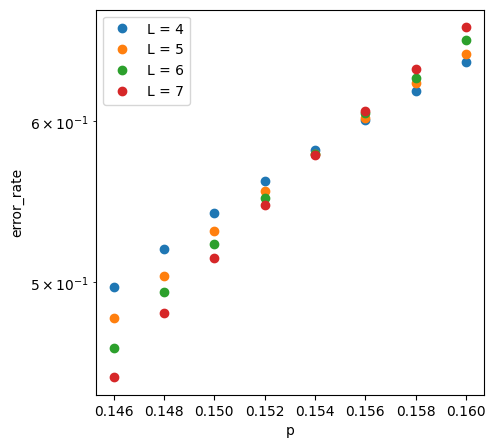

In [2]:
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

p = [0.146, 0.148, 0.15, 0.152, 0.154, 0.156, 0.158, 0.16]
L = [4, 5, 6, 7]

error_rate = np.array([np.mean(runs[:, 0:4, :], axis=(0, 1)),
                       np.mean(runs[:, 4:8, :], axis=(0, 1)),
                       np.mean(runs[:, 8:12, :], axis=(0, 1)),
                       np.mean(runs[:, 12:16, :], axis=(0, 1))])

plt.figure(figsize=(5, 5))
for l in range(len(L)):
    plt.plot(p, error_rate[l], 'o', label=f'L = {L[l]}')
    
plt.yscale('log')
plt.xlabel('p')
plt.ylabel('error_rate')
plt.legend()
plt.show()

In [3]:
from scipy.optimize import curve_fit

p = np.tile(np.array([0.146, 0.148, 0.15, 0.152, 0.154, 0.156, 0.158, 0.16]), 4)
L = np.repeat(np.array([4,5,6,7]), 8)
rate = error_rate.flatten()
n = 4 * 10**4
rate_error = np.array([])
for i in range(len(p)):
    se = (rate[i]*(1-rate[i])/n)**(1/2)
    rate_error = np.append(rate_error, se)

In [4]:
# Define the model
def model(pL, pc, nu, A, B, C):
    p, L = pL
    return A + B*(p-pc)*(L**(1/nu)) + C*((p-pc)**2)*(L**(2/nu))

# Perform the fit with error bars
popt, pcov, infodict, mesg, ier = curve_fit(model, (p, L), rate, full_output=True, sigma=rate_error, absolute_sigma=True)

# Results
print("Fitted parameters:", popt)

# Calculate standard deviations of parameters
perr = np.sqrt(np.diag(pcov))
print("Parameter standard deviations:", perr)
np.sum(np.abs(infodict['fvec']))

Fitted parameters: [ 0.15475368  1.36476255  0.58826231  3.66268007 -4.33816844]
Parameter standard deviations: [2.51623403e-04 6.90803500e-02 3.15887240e-03 2.34499483e-01
 1.98108818e+00]


np.float64(8.161424098019676)

In [5]:
# Define the model
def model(pL, pc, nu, A, B, C, D):
    p, L = pL
    return A + B*(p-pc)*(L**(1/nu)) + C*((p-pc)**2)*(L**(2/nu)) + D*((p-pc)**3)*(L**(3/nu))

# Perform the fit with error bars
popt, pcov, infodict, mesg, ier = curve_fit(model, (p, L), rate, p0=[0.2, 1.5, 0.25, 0, 0, 0], full_output=True, sigma=rate_error, absolute_sigma=True)

# Results
print("Fitted parameters:", popt)

# Calculate standard deviations of parameters
perr = np.sqrt(np.diag(pcov))
print("Parameter standard deviations:", perr)
np.sum(np.abs(infodict['fvec']))

Fitted parameters: [ 0.15476396  1.37492274  0.58830884  3.68540285 -3.81064461 31.83923606]
Parameter standard deviations: [2.56710073e-04 8.13779431e-02 3.17200061e-03 2.52697577e-01
 3.01252741e+00 1.35456394e+02]


np.float64(8.256768214132816)

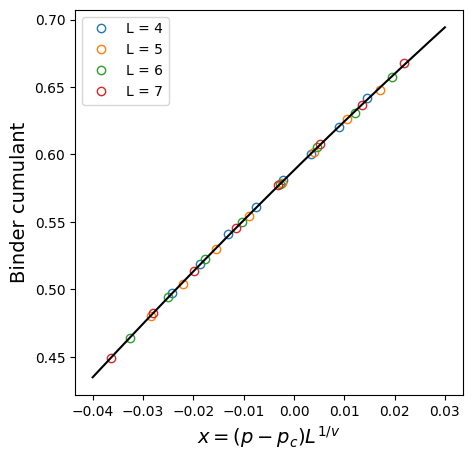

In [8]:
pc = 0.15475368
nu = 1.36476255
A = 0.58826231
B = 3.66268007
C = -4.33816844
# D = -149.66927112
p = [0.146, 0.148, 0.15, 0.152, 0.154, 0.156, 0.158, 0.16]
L = [4, 5, 6, 7]
error_rate = np.array([np.mean(runs[:, 0:4, :], axis=(0, 1)),
                       np.mean(runs[:, 4:8, :], axis=(0, 1)),
                       np.mean(runs[:, 8:12, :], axis=(0, 1)),
                       np.mean(runs[:, 12:16, :], axis=(0, 1))])

x = np.zeros((len(L), len(p)))
plt.figure(figsize=(5, 5))
for l in range(len(L)):
    for i in range(len(p)):
        x[l][i] = (p[i]-pc) * (L[l]**(1/nu))
    plt.plot(x[l], error_rate[l], 'o', markerfacecolor='none', label=f'L = {L[l]}')
x_data = np.linspace(-0.04, 0.03, 1000)
y_data = A + B*x_data + C*(x_data**2) #+D*(x_data**3)
plt.plot(x_data, y_data, color = 'k')

#ax = plt.gca()
#ax.spines['top'].set_visible(False)
#ax.spines['right'].set_visible(False)

#plt.yscale('log')
plt.xlabel('$x=(p-p_c)L^{1/v}$', fontsize=14)
plt.ylabel('Binder cumulant', fontsize=14)
plt.legend()
#plt.savefig('modified-D4.png', dpi=600, bbox_inches='tight')
plt.show()